# 03 · Advanced Analysis — Aberrations, Propagation, Through-Focus

Once you have a phase mask, the analysis layer answers:
- *How aberrated is it?* → Zernike decomposition.
- *Where does it focus?* → angular-spectrum propagation through-focus.
- *What does the resolution look like?* → MTF curves and MTF50.

We compare an **ideal** Fresnel-zone lens against the same lens with
synthetic aberration injected, to make the metrics tangible.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt

from metaopticsai.store.memory import InMemoryArtifactStore
from metaopticsai.physics.backends.base import BackendRegistry
from metaopticsai.physics.backends.analytical import AnalyticalBackend
from metaopticsai.tools import build_tool_registry
from metaopticsai.phase.profiles import fresnel_zone_lens

store = InMemoryArtifactStore()
backends = BackendRegistry(); backends.register(AnalyticalBackend())
tools = build_tool_registry(store, backends)

WL_NM = 532; F_UM = 100; D_UM = 50; PX_UM = 0.35

## 1 · Build an ideal mask and an aberrated copy

We add 0.4 rad of synthetic spherical aberration (Noll Z₁₁) to the
ideal FZL phase to see how it shows up in every downstream metric.

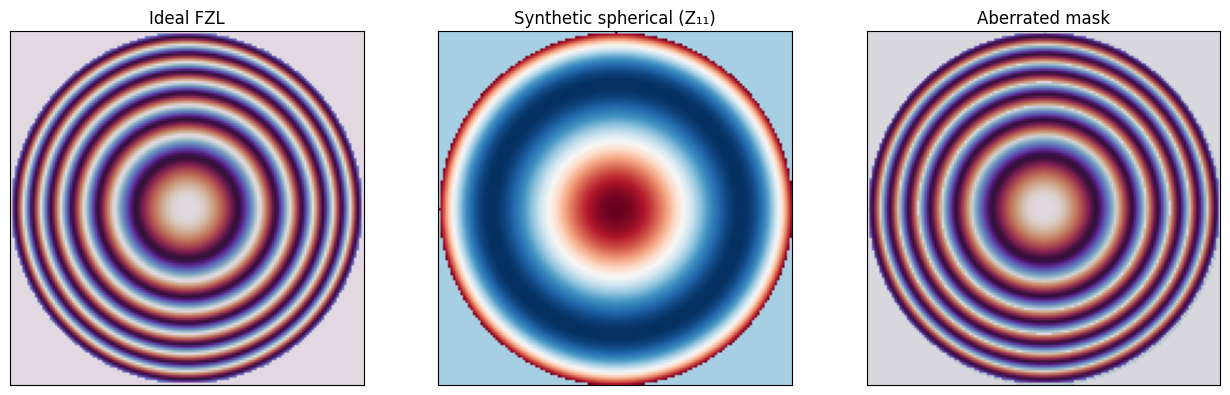

In [2]:
ideal_mask = fresnel_zone_lens(
    wavelength_nm=WL_NM, focal_length_um=F_UM,
    diameter_um=D_UM, pixel_size_um=PX_UM, circular=True,
)

# Spherical aberration: Z_11 ∝ (6r⁴ − 6r² + 1) within unit disk.
n = ideal_mask.shape[0]
y, x = np.mgrid[-n/2:n/2, -n/2:n/2]
r = np.hypot(x, y) / (n / 2)
mask_disk = r <= 1
sph_ab = np.where(mask_disk, 6*r**4 - 6*r**2 + 1, 0.0)
aberrated_mask = ideal_mask + 0.4 * sph_ab

ideal_handle = store.put("phase_mask", ideal_mask, wavelength_nm=WL_NM)
aberr_handle = store.put("phase_mask", aberrated_mask, wavelength_nm=WL_NM)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(ideal_mask, cmap="twilight");      ax[0].set_title("Ideal FZL")
ax[1].imshow(0.4 * sph_ab, cmap="RdBu_r");      ax[1].set_title("Synthetic spherical (Z₁₁)")
ax[2].imshow(aberrated_mask, cmap="twilight"); ax[2].set_title("Aberrated mask")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout()

## 2 · Compare PSF, MTF, Strehl

In [3]:
def measure(handle, label):
    psf = tools.get("analyze_psf").call_sync({
        "mask_handle": handle, "wavelength_nm": WL_NM,
        "pixel_size_um": PX_UM, "focal_length_um": F_UM, "pad_factor": 4,
    })
    mtf = tools.get("analyze_mtf").call_sync({
        "psf_handle": psf["handle"], "pixel_size_um": PX_UM,
        "wavelength_nm": WL_NM, "focal_length_um": F_UM,
    })
    print(f"{label}: Strehl {psf['strehl_ratio']:.3f}, "
          f"FWHM {psf['fwhm_x_um']:.3f} µm, MTF50 {mtf['mtf50_lpmm']:.1f} lp/mm")
    return psf, mtf

psf_i, mtf_i = measure(ideal_handle, "Ideal    ")
psf_a, mtf_a = measure(aberr_handle, "Aberrated")

Ideal    : Strehl 0.001, FWHM 2.681 µm, MTF50 10.4 lp/mm
Aberrated: Strehl 0.001, FWHM 2.681 µm, MTF50 10.5 lp/mm


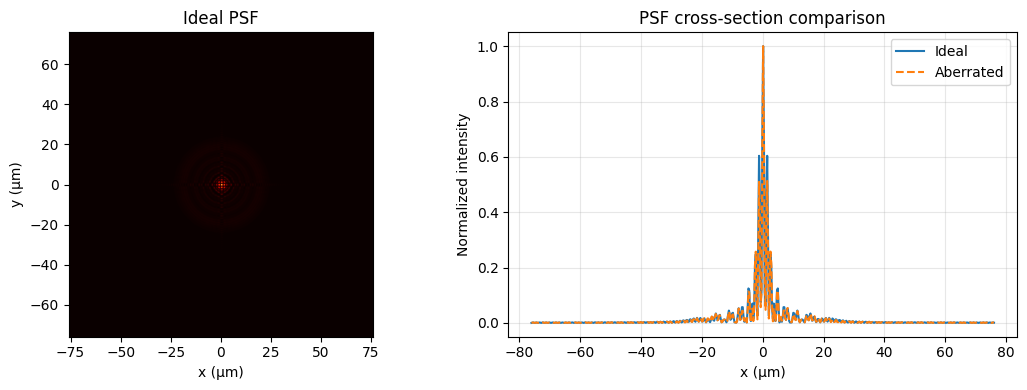

In [4]:
psf_i_2d = store.get(psf_i["handle"]).payload["psf_2d"]
psf_a_2d = store.get(psf_a["handle"]).payload["psf_2d"]
x_um = store.get(psf_i["handle"]).payload["x_um"]
c = psf_i_2d.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(psf_i_2d, extent=[x_um.min(), x_um.max()]*2, cmap="hot")
axes[0].set_title("Ideal PSF")
axes[0].set(xlabel="x (µm)", ylabel="y (µm)")

axes[1].plot(x_um, psf_i_2d[c, :]/psf_i_2d.max(), label="Ideal")
axes[1].plot(x_um, psf_a_2d[c, :]/psf_a_2d.max(), label="Aberrated", linestyle="--")
axes[1].set(xlabel="x (µm)", ylabel="Normalized intensity",
            title="PSF cross-section comparison")
axes[1].grid(alpha=.3); axes[1].legend()
plt.tight_layout()

## 3 · Zernike decomposition

15-term Noll basis. The injected aberration should light up Z₁₁.

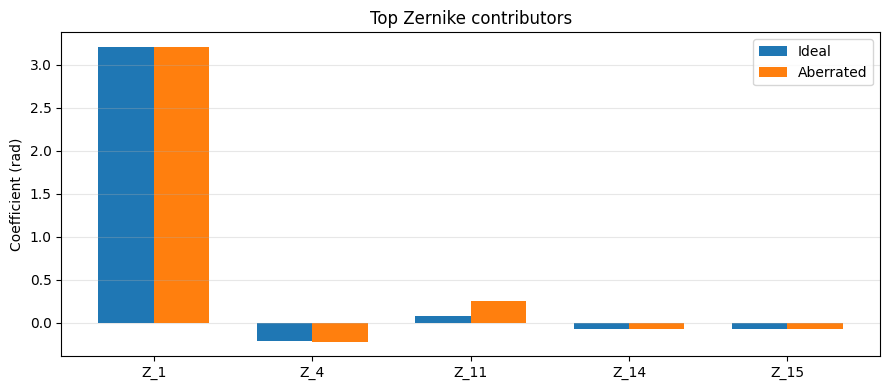

In [5]:
zer_i = tools.get("zernike_decompose").call_sync({"mask_handle": ideal_handle, "n_terms": 15})
zer_a = tools.get("zernike_decompose").call_sync({"mask_handle": aberr_handle, "n_terms": 15})

def coeffs(z):
    return {t["noll"]: t["coeff_rad"] for t in z["top_aberrations"]}

ci, ca = coeffs(zer_i), coeffs(zer_a)
all_nolls = sorted(set(ci) | set(ca))
vi = [ci.get(j, 0.0) for j in all_nolls]
va = [ca.get(j, 0.0) for j in all_nolls]
x = np.arange(len(all_nolls)); width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, vi, width, label="Ideal", color="tab:blue")
ax.bar(x + width/2, va, width, label="Aberrated", color="tab:orange")
ax.set_xticks(x); ax.set_xticklabels([f"Z_{j}" for j in all_nolls])
ax.set_ylabel("Coefficient (rad)"); ax.set_title("Top Zernike contributors")
ax.legend(); ax.grid(alpha=.3, axis="y")
plt.tight_layout()

## 4 · Through-focus scan via angular-spectrum propagation

Walk the field through a stack of distances around the nominal focal
plane; track the on-axis intensity. The peak tells you where the actual
focus is.

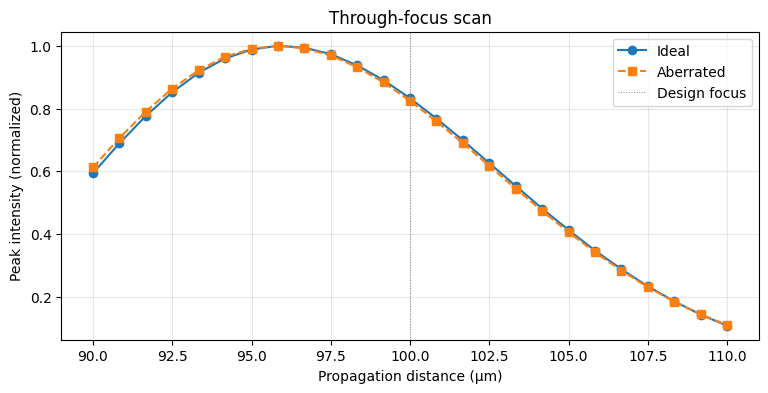

In [7]:
distances_um = np.linspace(F_UM - 10, F_UM + 10, 25)
peaks_ideal, peaks_aberr = [], []
for z in distances_um:
    for handle, peaks in [(ideal_handle, peaks_ideal),
                          (aberr_handle, peaks_aberr)]:
        result = tools.get("propagate_field").call_sync({
            "mask_handle": handle, "wavelength_nm": WL_NM,
            "pixel_size_um": PX_UM, "propagation_distance_um": float(z),
            "refractive_index": 1.0,
        })
        peaks.append(result["peak_intensity"])

plt.figure(figsize=(9, 4))
plt.plot(distances_um, np.array(peaks_ideal) / max(peaks_ideal), "o-", label="Ideal")
plt.plot(distances_um, np.array(peaks_aberr) / max(peaks_aberr), "s--", label="Aberrated")
plt.axvline(F_UM, color="gray", lw=.7, ls=":", label="Design focus")
plt.xlabel("Propagation distance (µm)")
plt.ylabel("Peak intensity (normalized)")
plt.title("Through-focus scan")
plt.legend(); plt.grid(alpha=.3)

**Read this plot as:** sharper peak = tighter focus. The aberrated lens
spreads energy through-focus (focal shift + degraded depth-of-focus).